# Screen Time Analysis for Kids(Ages 8-18)

## Recommendation System

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Importing the user-defined class 
from recommendation_system import ScreenTimeRecommendationSystem
# Initialize with your dataset
rec_system = ScreenTimeRecommendationSystem('Indian_Kids_Screen_Time.csv')

INITIALIZING SCREEN TIME RECOMMENDATION SYSTEM

📂 Loading dataset...
✓ Loaded 9712 records

🧹 Cleaning data...
✓ Removed 44 duplicates

📊 Calculating baseline statistics...
✓ Overall Average: 4.37 hours/day

✅ System ready!


In [3]:
# Comparison plot between the child and some categories that the child belongs to.
def plot_peer_comparison(analysis):
    # Calculate all group averages from analysis data
    overall_avg = analysis['comparisons']['Overall Average'][0]
    gender_avg = analysis['comparisons'][f"Gender ({analysis['gender']})"][0]
    device_avg = analysis['comparisons'][f"Device ({analysis['device']})"][0]
    age_group_avg = analysis['comparisons'][f"Age Group ({analysis['age_group']})"][0]
    location_avg = analysis['comparisons'][f"Location ({analysis['location']})"][0]
    screen_time = analysis['screen_time']
    
    # Print analysis (your style)
    print(f"\n📊 Analyzing: {analysis['age']}-year-old {analysis['gender']}, {analysis['location']}, {analysis['device']} user")
    print(f"   Screen time: {screen_time} hours/day")
    print(f"\n   Comparisons:")
    print(f"   - Child Average vs Overall Average ({overall_avg:.2f}h): {screen_time - overall_avg:+.2f}h")
    print(f"   - Child Average vs Gender Average ({gender_avg:.2f}h): {screen_time - gender_avg:+.2f}h")
    print(f"   - Child Average vs Device Average ({device_avg:.2f}h): {screen_time - device_avg:+.2f}h")
    print(f"   - Child Average vs Age Group Average ({age_group_avg:.2f}h): {screen_time - age_group_avg:+.2f}h")
    print(f"   - Child Average vs Location Average ({location_avg:.2f}h): {screen_time - location_avg:+.2f}h")
    
    # Prepare visualization data (your 6-bar chart)
    categories = [
        "Child's Usage",
        'Overall Avg',
        f'Gender\n({analysis["gender"]})',
        f'Device\n({analysis["device"]})',
        f'Age Group\n({analysis["age_group"]})',
        f'Location\n({analysis["location"]})'
    ]
    
    values = [screen_time, overall_avg, gender_avg, device_avg, age_group_avg, location_avg]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']
    
    # Create the plot (YOUR STYLE)
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(categories, values, color=colors, alpha=0.85, 
                   edgecolor='black', linewidth=1.2)
    
    # Customize
    ax.set_title(f'Screen Time Comparison: {analysis["age"]}-year-old {analysis["gender"]} ({analysis["device"]} user)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('Daily Screen Time (hours)', fontsize=12)
    ax.set_xlabel('Comparison Categories', fontsize=12)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.1,
                f'{value:.2f}h', ha='center', va='bottom', 
                fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.show()


In [4]:
# Dashboard for the child to view the visualizations on excess limit, health impacts, etc.
def create_dashboard(analysis,df):
    """Create a comprehensive 6-panel dashboard"""
    #df = rec_system.data
    fig, axes = plt.subplots(3, 2, figsize=(15, 15))
    fig.suptitle('Screen Time Analysis Dashboard', fontsize=16, fontweight='bold')

    # Panel 1: Peer Comparison
    categories = []
    peer_avgs = []
    for category, (avg, diff) in analysis['comparisons'].items():
        categories.append(category.split('(')[0].strip())
        peer_avgs.append(avg)

    axes[0, 0].bar(categories, peer_avgs, alpha=0.6, color='skyblue')
    bars1 = axes[0, 0].bar(categories, peer_avgs, alpha=0.6, color='skyblue')
    for bar in bars1:
        height = bar.get_height()
        axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,                 # small gap above bar
        f"{height:.2f}",
        ha='center', va='bottom',
        fontweight='bold', fontsize=10
        )
    axes[0, 0].axhline(y=analysis['screen_time'], color='red', linestyle='--', linewidth=2,)
    axes[0, 0].axhline(y=analysis['recommended_limit'], color='green', linestyle='--', linewidth=2,)
    axes[0, 0].set_title('Peer Group Comparison', fontweight='bold')
    axes[0, 0].set_ylabel('Hours/day')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(axis='y', alpha=0.3)
    from matplotlib.lines import Line2D
    custom_lines = [
    Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='Child Usage'),
    Line2D([0], [0], color='green', linestyle='--', linewidth=2, label='Usage Limit')]
    axes[0, 0].legend(handles=custom_lines, loc='lower right')
    
    # Panel 2: Usage vs Limit
    labels = ['Current\nUsage', 'Recommended\nLimit', 'Excess']
    values = [
        analysis['screen_time'],
        analysis['recommended_limit'],
        max(0, analysis['exceeds_by'])
    ]
    colors = ['#ff9999', '#66b3ff', '#ffcc99']

    axes[0, 1].bar(labels, values, color=colors, alpha=0.7)
    bars2 = axes[0, 1].bar(labels, values, color=colors, alpha=0.7)
    for bar in bars2:
        height = bar.get_height()
        axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,                 # small gap above bar
        f"{height:.2f}",
        ha='center', va='bottom',
        fontweight='bold', fontsize=10
        )
    axes[0, 1].set_title('Usage vs Recommended Limit', fontweight='bold')
    axes[0, 1].set_ylabel('Hours/day')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # Panel 3: Severity Gauge (Show only current severity)
    severity_levels = ['Healthy', 'Moderate', 'High', 'Critical']
    severity_colors = ['#00ff00', '#ffff00', '#ff9900', '#ff0000']
    current_severity = analysis['severity']

    # Get the index and color for current severity
    severity_index = severity_levels.index(current_severity)
    current_color = severity_colors[severity_index]

    # Show only the current severity level
    axes[1, 0].barh([current_severity], [1], color=current_color, alpha=0.8, edgecolor='black', linewidth=2)
    axes[1, 0].set_title('Severity Classification', fontweight='bold')
    axes[1, 0].set_xlabel('Level')
    axes[1, 0].set_xlim(0, 1.2)
    axes[1, 0].set_yticks([current_severity])  # Show only current severity on y-axis

    # Add text label showing the severity level
    axes[1, 0].text(0.5, 0, current_severity, ha='center', va='center', 
                fontsize=14, fontweight='bold', color='white')

    # Panel 4: Educational to Recreational Ratio Comparison
    child_ratio = analysis.get('edu_rec_ratio', 0)
    dataset_avg_ratio = df['Educational_to_Recreational_Ratio'].mean()
    ratio_labels = ['Child\nRatio', 'Dataset Avg\nRatio']
    ratio_values = [child_ratio if child_ratio != 'N/A' else 0, dataset_avg_ratio]
    ratio_colors = ['#2196F3', '#9E9E9E']
    bars5 = axes[1, 1].bar(ratio_labels, ratio_values, color=ratio_colors,   # ← Changed
                       alpha=0.8, edgecolor='black', linewidth=1.5)

    axes[1, 1].set_ylabel('Edu/Rec Ratio', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Educational to Recreational Ratio', fontweight='bold')
    axes[1, 1].axhline(y=1, color='green', linestyle='--', linewidth=2, label='Ideal (1:1)')
    axes[1, 1].legend(loc='upper right')
    axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels
    for bar, val in zip(bars5, ratio_values):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, height + 0.02,  # ← Changed
                    f'{val:.2f}', ha='center', va='bottom', 
                    fontweight='bold', fontsize=11)

    # Add interpretation
    if child_ratio != 'N/A' and child_ratio > dataset_avg_ratio:
        interpretation = "✅ Better than average"
        interp_color = 'green'
    elif child_ratio != 'N/A' and child_ratio < dataset_avg_ratio:
        interpretation = "⚠️ Below average"
        interp_color = 'orange'
    else:
        interpretation = "➖ Similar to average"
        interp_color = 'gray'

    axes[1, 1].text(0.5, 0.95, interpretation, transform=axes[1, 1].transAxes,  # ← Changed
                ha='center', va='top', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor=interp_color, alpha=0.3))

    # Panel 5: Health Impacts - Horizontal Bar Chart
    child_impacts = analysis.get('health_impacts', ['None'])
    if isinstance(child_impacts, str):
        child_impacts = [child_impacts]

    # Count health impacts in dataset
    from collections import Counter
    all_impacts = []
    for impacts in df['Health_Impacts'].dropna():
        if isinstance(impacts, str):
            all_impacts.extend([i.strip() for i in impacts.split(',')])

    impact_counts = Counter(all_impacts)
    top_impacts = dict(impact_counts.most_common(5))

    # Prepare data for horizontal bar chart
    impact_labels = list(top_impacts.keys())
    impact_values = list(top_impacts.values())

    # Color bars based on whether child has them
    bar_colors = ['#FF6B6B' if label in child_impacts else '#9E9E9E' 
              for label in impact_labels]

    # Create horizontal bar chart
    bars = axes[2, 0].barh(impact_labels, impact_values, color=bar_colors, 
                       alpha=0.8, edgecolor='black', linewidth=1.5)

    axes[2, 0].set_title('Health Impacts Frequency', fontweight='bold')
    axes[2, 0].set_xlabel('Number of Children', fontsize=11)
    axes[2, 0].grid(axis='x', alpha=0.3, linestyle='--')

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, impact_values)):
        width = bar.get_width()
        axes[2, 0].text(width + max(impact_values)*0.02, bar.get_y() + bar.get_height()/2,
                    f'{val} ({val/len(df)*100:.1f}%)', 
                    ha='left', va='center', fontweight='bold', fontsize=10)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#FF6B6B', edgecolor='black', label="Child's Impacts"),
        Patch(facecolor='#9E9E9E', edgecolor='black', label='Other Impacts')
    ]
    axes[2, 0].legend(handles=legend_elements, loc='lower right', fontsize=10)

        
    # Panel 6: Profile Summary
    axes[2, 1].axis('off')

    # Get educational/recreational data (with defaults if not present)
    edu_hours = analysis.get('educational_hours', 'N/A')
    rec_hours = analysis.get('recreational_hours', 'N/A')
    edu_rec_ratio = analysis.get('edu_rec_ratio', 'N/A')
    health_impacts = analysis.get('health_impacts', ['Not specified'])

    # Format health impacts as a string
    if isinstance(health_impacts, list):
        health_str = ', '.join(health_impacts)
    else:
        health_str = str(health_impacts)

    # Format educational/recreational hours
    if edu_hours != 'N/A':
        edu_str = f"{edu_hours:.2f} h/day"
        rec_str = f"{rec_hours:.2f} h/day"
        ratio_str = f"{edu_rec_ratio:.2f}"
    else:
        edu_str = "N/A"
        rec_str = "N/A"
        ratio_str = "N/A"

    profile_text = f"""
    USER PROFILE
    ━━━━━━━━━━━━━━━━━━━━
    Age: {analysis['age']} years
    Age Group: {analysis['age_group']}
    Gender: {analysis['gender']}
    Device: {analysis['device']}
    Location: {analysis['location']}

    SCREEN TIME ANALYSIS
    ━━━━━━━━━━━━━━━━━━━━
    Current: {analysis['screen_time']:.2f} h/day
    Recommended: {analysis['recommended_limit']:.2f} h/day
    Difference: {analysis['exceeds_by']:.2f} h/day
    Severity: {analysis['severity']}
    Educational: {edu_str}
    Recreational: {rec_str}
    Edu/Rec Ratio: {ratio_str}

    HEALTH IMPACTS
    ━━━━━━━━━━━━━━━━━━━━
    {health_str}
    """

    axes[2, 1].text(0.1, 0.5, profile_text, fontsize=11, family='monospace',
                verticalalignment='center')

    plt.tight_layout()
    plt.show()


🎯 SCREEN TIME RECOMMENDATION SYSTEM - USER INPUT



📅 Enter age (8-18):  10

👤 Enter gender (Male/Female):  female



📱 Select primary device:
   1. Smartphone
   2. Laptop
   3. TV
   4. Tablet


Enter choice (1-4):  1

🏙️ Enter location (Urban/Rural):  urban

📚 Enter educational screen time (hours/day):  2

🎮 Enter recreational screen time (hours/day):  4



📊 Total Screen Time: 6.00 hours/day
📊 Educational to Recreational Ratio: 0.50

🏥 Select Health Impacts (separate multiple with commas):
   Options: Poor Sleep, Eye Strain, Anxiety, Behavioral Issues, None
   Example: Poor Sleep, Eye Strain



Enter health impacts:  Eye Strain,Poor Sleep


📊 PERSONALIZED SCREEN TIME ANALYSIS REPORT
👤 User Profile:
   Age: 10 years (8-10 years)
   Gender: Female
   Primary Device: Smartphone
   Location: Urban

📱 Screen Time Analysis:
   Current Usage: 6.00 hours/day
   Recommended Limit: 2.00 hours/day

   ⚠️  Exceeds by: 4.00 hours/day
   Severity Level: Critical
📈 Peer Group Comparisons:
   Overall Average: 4.37h (You: ↑ 1.63h)

   Gender (Female): 4.35h (You: ↑ 1.65h)

   Device (Smartphone): 4.41h (You: ↑ 1.59h)

   Age Group (8-10 years): 3.97h (You: ↑ 2.03h)

   Location (Urban): 4.36h (You: ↑ 1.64h)

💡 PERSONALIZED RECOMMENDATIONS:
   🚨 CRITICAL: Screen time is 4.0 hours ABOVE recommendations!
   💡 URGENT: Reduce screen time by 2-3 hours immediately and seek professional guidance.
   📱 Enable screen time limits using built-in features
   📱 Move distracting apps to folders or remove from home screen
   📱 Use grayscale mode to reduce appeal
   👶 Prioritize outdoor play and physical activities
   👶 Encourage creative activities like 

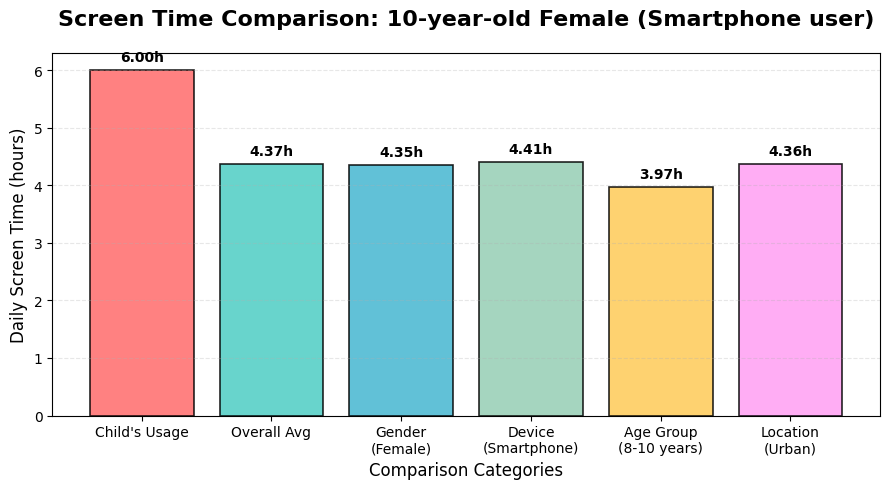

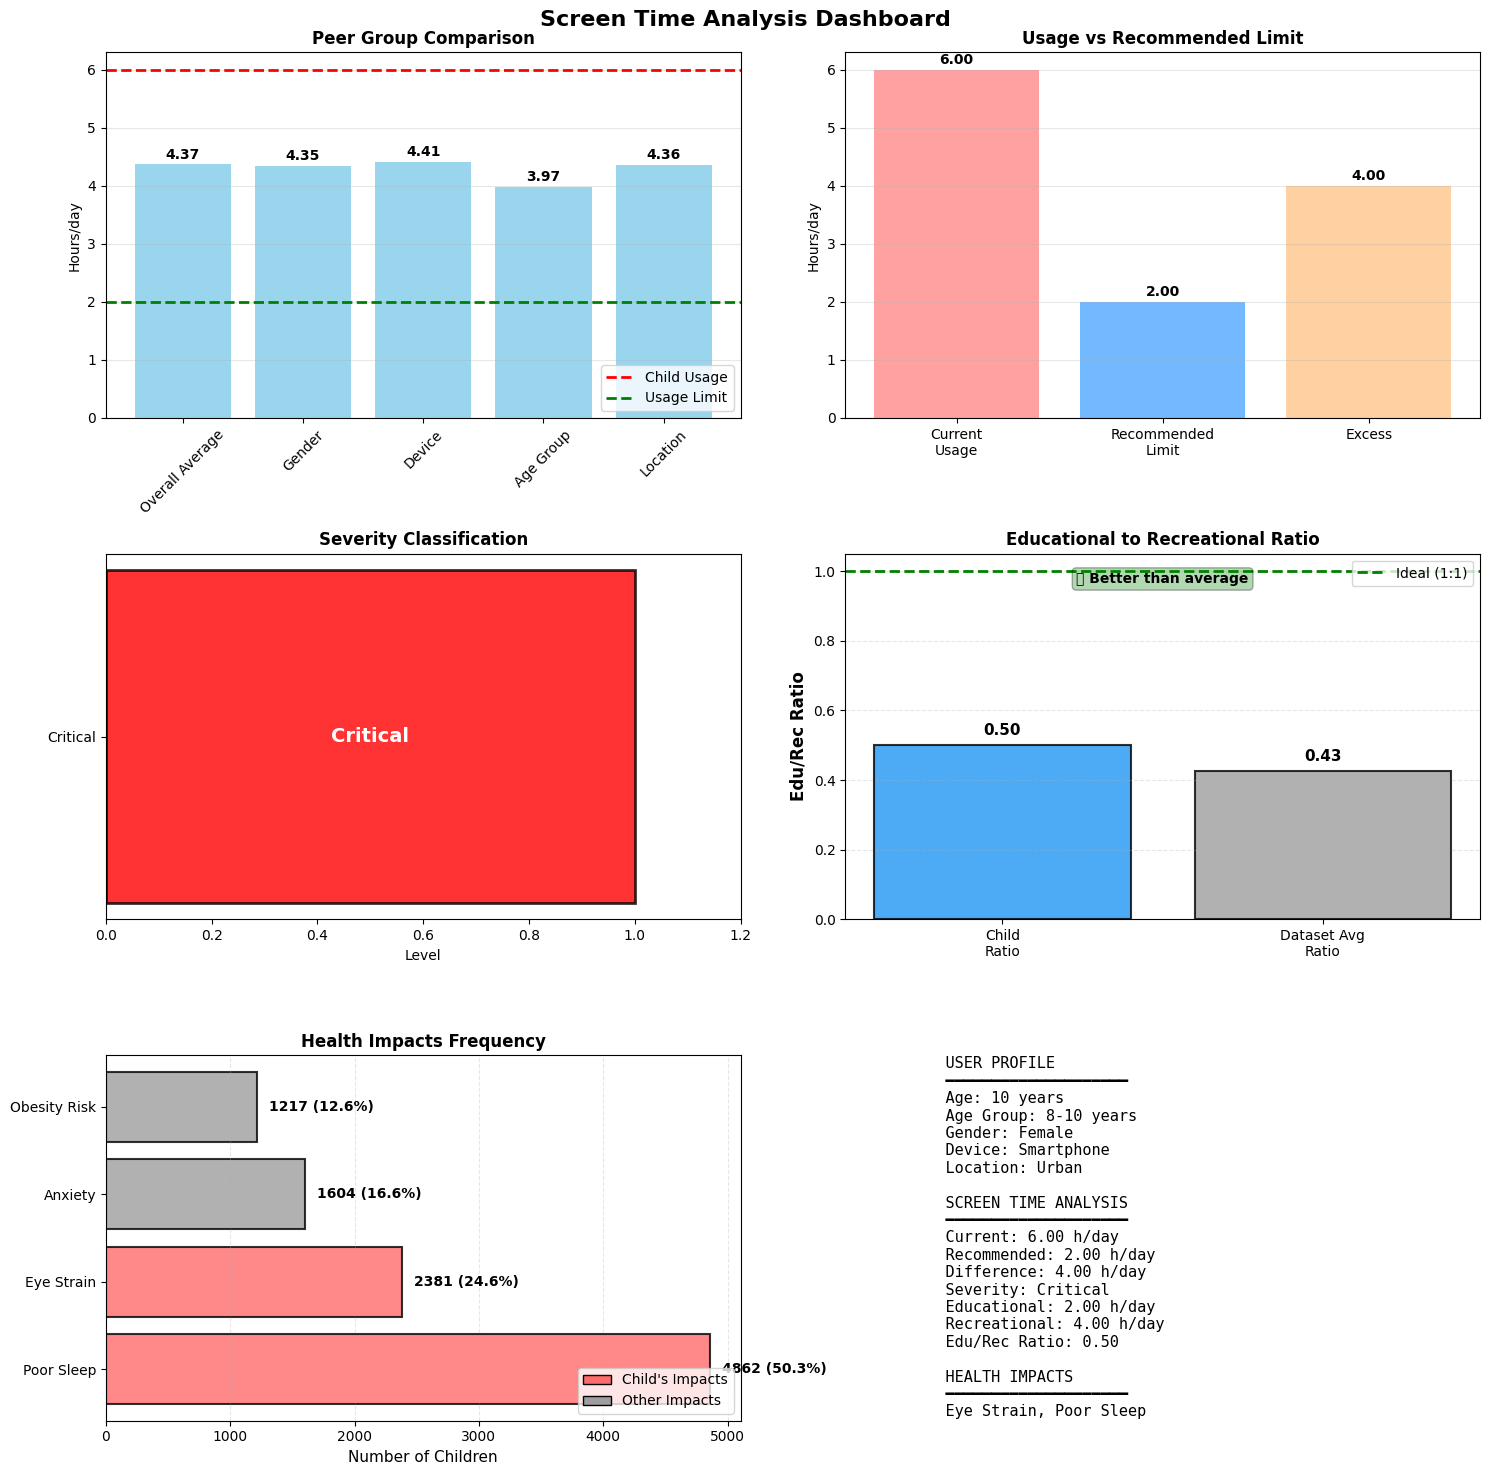


✅ All analysis complete!


In [5]:
# Importing the user-defined function and performing recommendation system analysis
from user_input import analyze_case
new_analysis, new_recs = analyze_case(rec_system)
plot_peer_comparison(new_analysis)
create_dashboard(new_analysis, rec_system.data)

print("\n✅ All analysis complete!")